# Food Microbiome Exposure (FME) Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
1. **Data Transfer** — Load all preprocessed datasets from both sources
2. **Data Mapping** — Map dietary food items to cFMD food categories
3. **FME Quantification** — Calculate a daily Food Microbiome Exposure score per fecal sample
4. **Statistical Dataset** — Assemble one clean table ready for statistical modelling

### Key structural note
> The Johnson et al. 2019 study has **34 participants**, each contributing multiple fecal samples across up to 17 study days.
> All FME scores are computed at the **fecal sample level** (one score per sample = one dietary day per person).
> Participant-level summaries are derived by aggregating across samples — **not** by treating samples as independent observations.
> The unit of analysis for statistical models is the **fecal sample**, with participant included as a random effect.


---
## Section 1 – Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


In [2]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"
sys.path.insert(0, str(_root))


---
## Section 2 – Data Transfer: Load All Datasets

### Source 1 — Johnson et al. 2019 (gut microbiome + diet)
34 participants · up to 17 fecal samples each · 566 samples total

### Source 2 — Carlino et al. 2024 — cFMD (food microbiome)
3,393 food samples · 5,057 microbial taxa


In [3]:
#Gut microbiome matrices (taxa × fecal samples)  
gut_microbiome_abundance  = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)

#Fecal sample metadata  
#index = fecal sample ID
#columns: UserName (= participant), StudyDayNo, Gender, Age, BMI, ...
fecal_sample_metadata     = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)

#Dietary consumption matrix (food items × fecal samples)
#rows = food items, columns = fecal sample IDs
#values = consumption amount of that food on that day
dietary_consumption_matrix= pd.read_csv(DATA_DIR / "diet_raw.csv")

#Daily nutrition totals 
#index = fecal sample ID
daily_nutrition_totals    = pd.read_csv(DATA_DIR / "nutrition_totals.csv",    index_col=0)

#Additional dietary features   
daily_fiber_scores        = pd.read_csv(DATA_DIR / "diet_fiber.csv")
daily_decay_scores        = pd.read_csv(DATA_DIR / "diet_decay.csv")
participant_fiber_avg     = pd.read_csv(DATA_DIR / "fiber_avg.csv")

#cFMD food microbiome abundance (food taxa × food samples)
#'StudyName__ShortSampleID' format
cfmd_food_abundance       = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_food_abundance       = cfmd_food_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

#cFMD sample metadata
#columns: sample_id, category, fermented/non-fermented, country, ...
cfmd_food_metadata        = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

#Verify participant count
n_participants = fecal_sample_metadata["UserName"].nunique()
n_fecal_samples= len(fecal_sample_metadata)

print(f"Participants          : {n_participants}  (expected: 34)")
print(f"Fecal samples total   : {n_fecal_samples}")
print(f"Avg samples/person    : {n_fecal_samples / n_participants:.1f}")
print()
print("Dataset sizes:")
for name, df in [
    ("gut_microbiome_abundance",   gut_microbiome_abundance),
    ("fecal_sample_metadata",      fecal_sample_metadata),
    ("dietary_consumption_matrix", dietary_consumption_matrix),
    ("daily_nutrition_totals",     daily_nutrition_totals),
    ("cfmd_food_abundance",        cfmd_food_abundance),
    ("cfmd_food_metadata",         cfmd_food_metadata),
]:
    print(f"  {name:<32} {str(df.shape)}")


Participants          : 34  (expected: 34)
Fecal samples total   : 566
Avg samples/person    : 16.6

Dataset sizes:
  gut_microbiome_abundance         (223, 483)
  fecal_sample_metadata            (566, 28)
  dietary_consumption_matrix       (1452, 568)
  daily_nutrition_totals           (580, 106)
  cfmd_food_abundance              (5057, 3393)
  cfmd_food_metadata               (3444, 32)


---
## Section 3 – Define the Analytical Sample Set

Only fecal samples that have **both** a gut microbiome measurement **and** a dietary record
form the analytical core. We identify these 475 samples here.


In [4]:
#Identify fecal sample IDs present in both gut microbiome and diet data
FECAL_SAMPLE_PREFIX = "MCT.f."

gut_microbiome_sample_ids = set(gut_microbiome_abundance.columns)
diet_record_sample_ids    = set(
    c for c in dietary_consumption_matrix.columns
    if c.startswith(FECAL_SAMPLE_PREFIX)
)

#Core analytical set: samples with BOTH gut microbiome AND diet record
analytical_sample_ids = sorted(gut_microbiome_sample_ids & diet_record_sample_ids)

print(f"Gut microbiome samples         : {len(gut_microbiome_sample_ids)}")
print(f"Diet record samples            : {len(diet_record_sample_ids)}")
print(f"Analytical samples (gut∩diet)  : {len(analytical_sample_ids)}")
print()

#Participants represented in the analytical set
analytical_participants = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids), "UserName"]
    .nunique()
)
print(f"Participants represented       : {analytical_participants} / {n_participants}")

#Samples per participant in the analytical set
samples_per_participant = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids)]
    .groupby("UserName")
    .size()
    .rename("n_analytical_samples")
)
print(f"Avg analytical samples/person  : {samples_per_participant.mean():.1f}")
print(f"Min / Max                      : {samples_per_participant.min()} / {samples_per_participant.max()}")


Gut microbiome samples         : 483
Diet record samples            : 566
Analytical samples (gut∩diet)  : 475

Participants represented       : 34 / 34
Avg analytical samples/person  : 14.0
Min / Max                      : 6 / 17


---
## Section 4 – FME Weights from cFMD

**Goal:** Derive a microbial richness weight for each cFMD food category.

**Why richness, not total abundance?**
The `combined_datasets` matrix stores relative abundance — each sample sums to 100 regardless of food type.
Total abundance is therefore uninformative as a weight.
**Microbial richness** (= number of distinct taxa detected per food sample) reflects how microbiome-diverse each food category truly is.

**Weight formula:**
$$w_c = \frac{\text{mean\_richness}_c - \min}{\max - \min} \quad \in [0, 1]$$

Weights are derived directly from the **cFMD food abundance matrix** — not assumed or hand-coded.


In [5]:
#Map cFMD column names → food category + fermentation status
#combined_datasets columns: 'StudyName__ShortSampleID'
#cfmd_food_metadata sample_id: 'ShortSampleID'

def extract_cfmd_short_id(column_name):
    """Strip the study name prefix from a combined_datasets column name."""
    return column_name.split("__")[-1] if "__" in column_name else column_name

#Remove the one duplicate sample_id (VB15-29) before indexing
cfmd_food_metadata_dedup = cfmd_food_metadata.drop_duplicates(
    subset="sample_id", keep="first"
)
print(f"cFMD metadata after dedup: {len(cfmd_food_metadata_dedup)} rows "
      f"(removed {len(cfmd_food_metadata) - len(cfmd_food_metadata_dedup)} duplicate)")

cfmd_id_to_meta = (
    cfmd_food_metadata_dedup
    .set_index("sample_id")[["category", "fermented/non-fermented"]]
    .to_dict(orient="index")
)

#Map each column in cfmd_food_abundance to its category and fermentation status
cfmd_column_to_category   = {}
cfmd_column_to_fermented  = {}
for col in cfmd_food_abundance.columns:
    short_id = extract_cfmd_short_id(col)
    if short_id in cfmd_id_to_meta:
        cfmd_column_to_category[col]  = cfmd_id_to_meta[short_id]["category"]
        cfmd_column_to_fermented[col] = cfmd_id_to_meta[short_id]["fermented/non-fermented"]

print(f"cFMD columns mapped: {len(cfmd_column_to_category)} / {cfmd_food_abundance.shape[1]}")


cFMD metadata after dedup: 3443 rows (removed 1 duplicate)
cFMD columns mapped: 3393 / 3393


In [6]:
# Compute microbial richness per food sample 
# Richness = number of non-zero taxa per food sample
cfmd_taxa_richness_per_sample = (cfmd_food_abundance > 0).sum(axis=0)

#Mean richness per cFMD food category
category_richness_values = {}
for col, category in cfmd_column_to_category.items():
    if col in cfmd_taxa_richness_per_sample.index:
        category_richness_values.setdefault(category, []).append(
            cfmd_taxa_richness_per_sample[col]
        )

cfmd_category_mean_richness = pd.Series(
    {cat: np.mean(vals) for cat, vals in category_richness_values.items()},
    name="mean_taxa_richness"
).sort_values(ascending=False)

#Normalize weights to [0, 1]
richness_min = cfmd_category_mean_richness.min()
richness_max = cfmd_category_mean_richness.max()
cfmd_category_weight_normalized = (
    (cfmd_category_mean_richness - richness_min) /
    (richness_max - richness_min)
).rename("fme_weight")

cfmd_weights_table = pd.concat(
    [cfmd_category_mean_richness, cfmd_category_weight_normalized], axis=1
)

print("FME weights per cFMD food category (from cFMD microbial richness):")
display(cfmd_weights_table.round(3))


FME weights per cFMD food category (from cFMD microbial richness):


,mean_taxa_richness,fme_weight
fruits_and_vegetables,120.1250,1.0000
fermented_seeds,69.8000,0.5510
fermented_tubers_and_roots,61.0420,0.4720
fish,51.7950,0.3900
fermented_legumes,49.2630,0.3670
meat,43.6490,0.3170
fermented_meat,37.4110,0.2610
fermented_fruits_and_vegetables,31.4810,0.2080
other,27.8750,0.1760
dairy,25.3960,0.1540


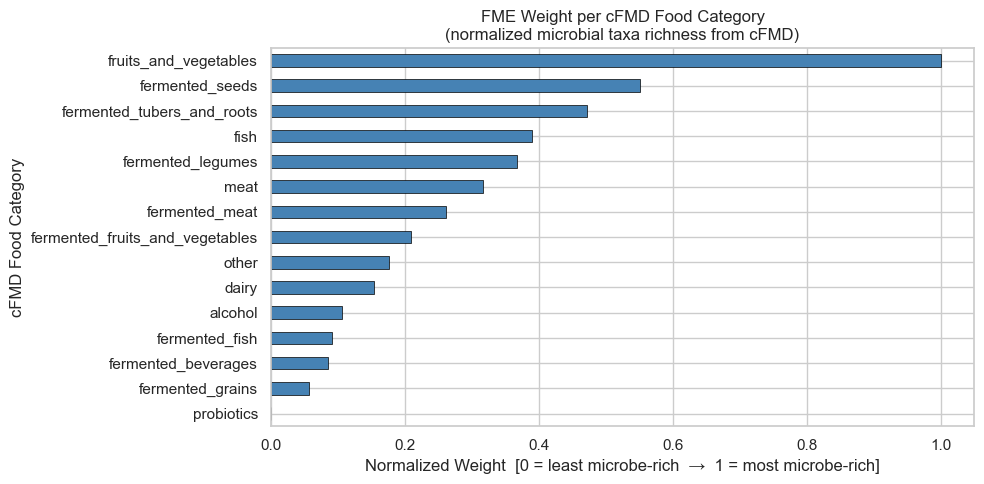

In [7]:
#Visualize FME weights
plt.figure(figsize=(10, 5))
cfmd_category_weight_normalized.sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black", linewidth=0.5
)
plt.title("FME Weight per cFMD Food Category\n(normalized microbial taxa richness from cFMD)")
plt.xlabel("Normalized Weight  [0 = least microbe-rich  →  1 = most microbe-rich]")
plt.ylabel("cFMD Food Category")
plt.tight_layout()
plt.show()


---
## Section 5 – Data Mapping: Diet Items → cFMD Food Categories

**Goal:** Map each food item in the Johnson et al. dietary records to a cFMD food category,
creating a unified representation of food-derived microbial exposure.

**Method:** Extract the L1 (top-level) taxonomy label from the `taxonomy` column of `diet_raw`
(e.g. `L1_Milk_and_Milk_Products` → `dairy`) and map it to the matching cFMD category.


In [8]:
#Extract L1 food category from taxonomy string
def extract_l1_food_category(taxonomy_string):
    """
    Extract the top-level food category (L1) from the hierarchical taxonomy string.
    Example: 'L1_Milk_and_Milk_Products;L2_...' → 'milk and milk products'
    """
    if pd.isna(taxonomy_string):
        return "unknown"
    l1_segment = str(taxonomy_string).split(";")[0]
    return l1_segment.replace("L1_", "").replace("_", " ").strip().lower()

dietary_consumption_matrix["diet_l1_category"] = (
    dietary_consumption_matrix["taxonomy"]
    .apply(extract_l1_food_category)
)

print("Unique L1 diet categories found:")
for cat, count in dietary_consumption_matrix["diet_l1_category"].value_counts().items():
    print(f"  {cat:<45} {count:>5} food items")


Unique L1 diet categories found:
  grain product                                   407 food items
  vegetables                                      315 food items
  meat poultry fish and mixtures                  240 food items
  sugars sweets and beverages                     153 food items
  milk and milk products                          112 food items
  dry beans peas other legumes nuts and seeds      84 food items
  fruits                                           74 food items
  fats oils and salad dressings                    36 food items
  eggs                                             31 food items


C:\Users\linoy\AppData\Local\Temp\ipykernel_20696\862340182.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["diet_l1_category"] = (


In [9]:
#Mapping table: diet L1 category to cFMD category 
DIET_L1_TO_CFMD_CATEGORY = {
    #Dairy
    "milk and milk products"            : "dairy",
    "dairy"                             : "dairy",
    "cheese"                            : "dairy",
    "yogurt"                            : "dairy",
    #Meat
    "meat poultry and game"             : "meat",
    "meat"                              : "meat",
    "poultry"                           : "meat",
    #Fish
    "fish and shellfish"                : "fish",
    "fish"                              : "fish",
    "seafood"                           : "fish",
    #Fruits and vegetables
    "vegetables and vegetable products" : "fruits_and_vegetables",
    "fruit"                             : "fruits_and_vegetables",
    "fruits"                            : "fruits_and_vegetables",
    "vegetables"                        : "fruits_and_vegetables",
    #Fermented grains
    "grain products"                    : "fermented_grains",
    "grains"                            : "fermented_grains",
    "bread"                             : "fermented_grains",
    "cereals and cereal products"       : "fermented_grains",
    #Alcohol / fermented beverages
    "alcoholic beverages"               : "alcohol",
    "alcohol"                           : "alcohol",
    "beverages"                         : "fermented_beverages",
    "nonalcoholic beverages"            : "fermented_beverages",
    #Legumes
    "legumes and legume products"       : "fermented_legumes",
    "legumes"                           : "fermented_legumes",
    "beans"                             : "fermented_legumes",
    #Seeds / nuts
    "nuts and seeds"                    : "fermented_seeds",
    "seeds"                             : "fermented_seeds",
    #Other / unmappable
    "fats and oils"                     : "other",
    "sugars and sweets"                 : "other",
    "soups sauces and gravies"          : "other",
    "mixed dishes"                      : "other",
    "snacks"                            : "other",
    "eggs"                              : "other",
    "spices and herbs"                  : "other",
    "unknown"                           : "unmapped",
}

dietary_consumption_matrix["cfmd_category"] = (
    dietary_consumption_matrix["diet_l1_category"]
    .map(DIET_L1_TO_CFMD_CATEGORY)
    .fillna("unmapped")
)

n_mapped   = (dietary_consumption_matrix["cfmd_category"] != "unmapped").sum()
n_unmapped = (dietary_consumption_matrix["cfmd_category"] == "unmapped").sum()
print(f"Food items mapped to a cFMD category : {n_mapped} / {len(dietary_consumption_matrix)}")
print(f"Food items unmapped                  : {n_unmapped}")


Food items mapped to a cFMD category : 532 / 1452
Food items unmapped                  : 920


C:\Users\linoy\AppData\Local\Temp\ipykernel_20696\3621762370.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["cfmd_category"] = (


In [10]:
#Attach FME weight to each food item
dietary_consumption_matrix["fme_weight"] = (
    dietary_consumption_matrix["cfmd_category"]
    .map(cfmd_category_weight_normalized.to_dict())
    .fillna(0.0)   #unmapped items get weight = 0
)

mapping_summary = (
    dietary_consumption_matrix
    .groupby(["diet_l1_category", "cfmd_category", "fme_weight"])
    .size()
    .reset_index(name="n_food_items")
    .sort_values("n_food_items", ascending=False)
)
print("Mapping summary (diet L1 → cFMD category → weight):")
display(mapping_summary)


Mapping summary (diet L1 → cFMD category → weight):


C:\Users\linoy\AppData\Local\Temp\ipykernel_20696\1938438746.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["fme_weight"] = (


,diet_l1_category,cfmd_category,fme_weight,n_food_items
4,grain product,unmapped,0.0000,407
8,vegetables,fruits_and_vegetables,1.0000,315
5,meat poultry fish and mixtures,unmapped,0.0000,240
7,sugars sweets and beverages,unmapped,0.0000,153
6,milk and milk products,dairy,0.1541,112
0,dry beans peas other legumes nuts and seeds,unmapped,0.0000,84
3,fruits,fruits_and_vegetables,1.0000,74
2,fats oils and salad dressings,unmapped,0.0000,36
1,eggs,other,0.1762,31


---
## Section 6 – FME Score Calculation

**Formula:**
$$\text{FME}_{sample} = \sum_{\text{food items}} \text{consumption}_{\text{food, sample}} \times w_{\text{cfmd\_category(food)}}$$

Where:
- $\text{consumption}_{\text{food, sample}}$ = amount consumed (from `diet_raw`, grams or servings)
- $w$ = normalized cFMD microbial richness weight for the food's category

**Important:** Each `sample` corresponds to **one dietary day for one participant**.
The result is a score per fecal sample — not per participant.
Participant-level scores are derived later by averaging across their samples.


In [11]:
#Subset diet matrix to analytical samples only
diet_abundance_matrix = (
    dietary_consumption_matrix[analytical_sample_ids]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fme_weight_vector = dietary_consumption_matrix["fme_weight"].values  # shape: (n_food_items,)

#Compute FME score: weighted sum of food consumption per sample
#Result: one FME score per fecal sample (= one dietary day per participant)
fme_score_per_sample = (
    diet_abundance_matrix
    .multiply(fme_weight_vector, axis=0)
    .sum(axis=0)
    .rename("fme_score_daily")
)
fme_score_per_sample.index.name = "fecal_sample_id"

print(f"FME scores computed for : {len(fme_score_per_sample)} fecal samples")
print(f"Score range             : {fme_score_per_sample.min():.4f} – {fme_score_per_sample.max():.4f}")
print(f"Score mean ± std        : {fme_score_per_sample.mean():.4f} ± {fme_score_per_sample.std():.4f}")
print(f"Non-zero scores         : {(fme_score_per_sample > 0).sum()}")
print()
display(fme_score_per_sample.reset_index().head(8))


FME scores computed for : 475 fecal samples
Score range             : 0.0000 – 331.2240
Score mean ± std        : 73.3252 ± 58.3071
Non-zero scores         : 437



,fecal_sample_id,fme_score_daily
0,MCT.f.0002,67.1961
1,MCT.f.0003,81.2412
2,MCT.f.0004,126.7711
3,MCT.f.0005,31.4846
4,MCT.f.0006,61.2266
5,MCT.f.0007,62.0231
6,MCT.f.0008,70.9874
7,MCT.f.0009,54.0086


In [12]:
#Participant level FME summary (aggregate across samples)
#Participant level values are used only for descriptive summaries,

fme_with_participant = pd.DataFrame({
    "fecal_sample_id" : fme_score_per_sample.index,
    "fme_score_daily" : fme_score_per_sample.values,
})
fme_with_participant["participant_id"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "UserName"]
    .values
)
fme_with_participant["study_day"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "StudyDayNo"]
    .values
)

#Participant-level summary (descriptive only)
participant_fme_summary = (
    fme_with_participant
    .groupby("participant_id")["fme_score_daily"]
    .agg(
        fme_mean     = "mean",
        fme_std      = "std",
        fme_min      = "min",
        fme_max      = "max",
        n_diet_days  = "count"
    )
    .reset_index()
)

print("Participant-level FME summary (descriptive — 34 participants):")
display(participant_fme_summary.sort_values("fme_mean", ascending=False).head(10))


Participant-level FME summary (descriptive — 34 participants):


,participant_id,fme_mean,fme_std,fme_min,fme_max,n_diet_days
1,MCTs03,147.8899,45.7548,68.0651,243.3253,12
5,MCTs07,143.4859,48.3133,86.0332,243.8429,16
2,MCTs04,143.1190,81.0506,36.6199,331.2240,15
6,MCTs08,140.2178,33.6074,84.4009,220.3516,17
14,MCTs16,130.9598,45.2371,69.7540,221.0863,14
27,MCTs31,128.7335,37.7598,83.9027,208.7920,15
23,MCTs26,122.0334,71.3654,24.5678,315.7055,17
16,MCTs19,99.4541,40.7179,14.6490,166.4480,15
17,MCTs20,88.6724,51.9185,24.4219,178.8966,12
24,MCTs27,85.2074,47.0410,5.0752,165.2448,14


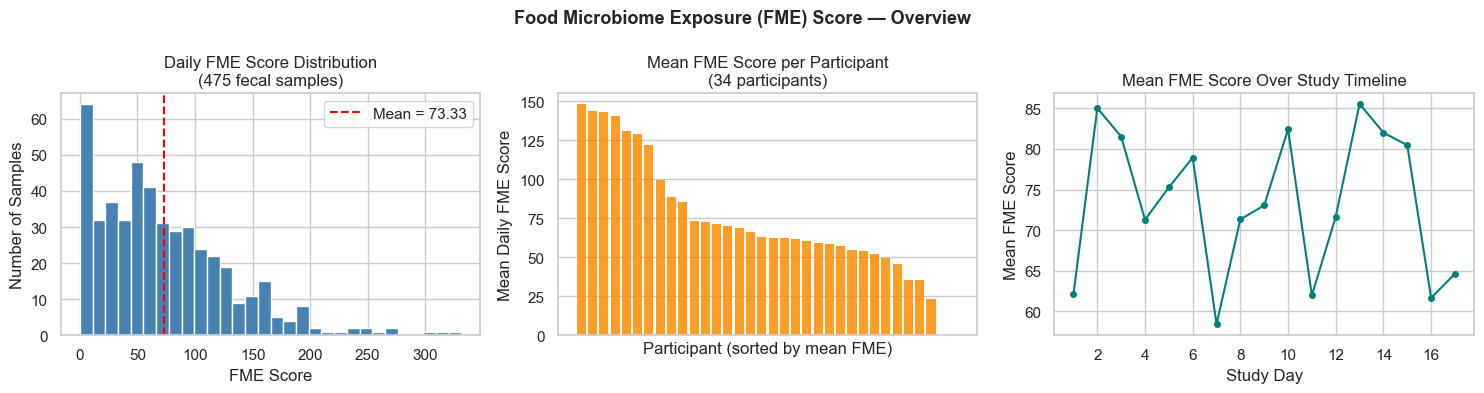

In [13]:
#Visualize FME scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Distribution of daily FME scores across all fecal samples
axes[0].hist(fme_score_per_sample.values, bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(fme_score_per_sample.mean(), color="red", linestyle="--",
                label=f"Mean = {fme_score_per_sample.mean():.2f}")
axes[0].set_title("Daily FME Score Distribution\n(475 fecal samples)")
axes[0].set_xlabel("FME Score")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

#Mean FME per participant (sorted)
sorted_participants = participant_fme_summary.sort_values("fme_mean", ascending=False)
axes[1].bar(range(len(sorted_participants)), sorted_participants["fme_mean"],
            color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Mean FME Score per Participant\n({len(sorted_participants)} participants)")
axes[1].set_xlabel("Participant (sorted by mean FME)")
axes[1].set_ylabel("Mean Daily FME Score")
axes[1].set_xticks([])

#FME over study timeline (mean per study day)
fme_by_day = fme_with_participant.groupby("study_day")["fme_score_daily"].mean()
axes[2].plot(fme_by_day.index, fme_by_day.values,
             marker="o", color="teal", linewidth=1.5, markersize=4)
axes[2].set_title("Mean FME Score Over Study Timeline")
axes[2].set_xlabel("Study Day")
axes[2].set_ylabel("Mean FME Score")

plt.suptitle("Food Microbiome Exposure (FME) Score — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 7 – Gut Microbiome Alpha Diversity per Fecal Sample

Compute **Shannon entropy** for each fecal sample as a measure of gut microbial richness and evenness.
This is the primary outcome variable (composition proxy) at the sample level.


In [14]:
#Alpha diversity metrics per fecal sample

#Computing Shannon entropy using the formula below, where p_i is the proportion of each taxon in the sample
#Shannon entropy H = -Σ p_i * log(p_i) for non zero taxa
def compute_shannon_entropy(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    return float(-np.sum(prop * np.log(prop)))

#Computing richness of taxa per sample
#Richness = number of non-zero taxa
def compute_richness(sample_val):
    pos_val = sample_val[sample_val > 0]
    return int(len(pos_val))

#Computing Simpson diversity using the formula below
#Simpson diversity = 1 - Σ p_i^2
def compute_simpson_diversity(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    return float(1 - np.sum(prop ** 2))

#Computing Inverse Simpson using the formula below
#Inverse Simpson = 1 / Σ p_i^2
def compute_inverse_simpson(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    denominator = np.sum(prop ** 2)
    if denominator == 0:
        return np.nan
    return float(1 / denominator)

#Computing Pielou evenness using the formula below
#Pielou evenness = Shannon / log(richness)
def compute_pielou_evenness(sample_val):
    pos_val = sample_val[sample_val > 0]
    richness = len(pos_val)

    if richness <= 1:
        return np.nan

    if pos_val.sum() == 0:
        return np.nan

    prop = pos_val / pos_val.sum()
    shannon = -np.sum(prop * np.log(prop))

    return float(shannon / np.log(richness))


gut_microbiome_analytical = gut_microbiome_abundance[analytical_sample_ids]

shannon_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_shannon_entropy, axis=0)
    .rename("shannon_diversity")
)

richness_per_sample = (
    gut_microbiome_analytical
    .apply(compute_richness, axis=0)
    .rename("richness")
)

simpson_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_simpson_diversity, axis=0)
    .rename("simpson_diversity")
)

inverse_simpson_per_sample = (
    gut_microbiome_analytical
    .apply(compute_inverse_simpson, axis=0)
    .rename("inverse_simpson")
)

pielou_evenness_per_sample = (
    gut_microbiome_analytical
    .apply(compute_pielou_evenness, axis=0)
    .rename("pielou_evenness")
)

alpha_diversity_per_sample = pd.concat(
    [
        shannon_diversity_per_sample,
        richness_per_sample,
        simpson_diversity_per_sample,
        inverse_simpson_per_sample,
        pielou_evenness_per_sample,
    ],
    axis=1
)

alpha_diversity_per_sample.index.name = "fecal_sample_id"

print(f"Alpha diversity computed for {alpha_diversity_per_sample.shape[0]} samples")
display(alpha_diversity_per_sample.describe().T.round(3))

Alpha diversity computed for 475 samples


,count,mean,std,min,25%,50%,75%,max
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
richness,475.0000,203.5620,11.9540,140.0000,198.0000,207.0000,212.0000,220.0000
simpson_diversity,475.0000,0.8600,0.0760,0.4650,0.8310,0.8860,0.9100,0.9570
inverse_simpson,475.0000,8.7810,3.6000,1.8690,5.9330,8.7990,11.1220,23.3370
pielou_evenness,475.0000,0.5390,0.0750,0.2990,0.4930,0.5560,0.5920,0.6940


---
## Section 8 – Gut Microbiome Stability per Participant

**Stability** = how consistent is a participant's gut microbiome across their sampling days?

We use the **coefficient of variation (CV)** of Shannon diversity across a participant's samples:
$$CV_{participant} = \frac{\sigma(\text{Shannon})}{\mu(\text{Shannon})}$$

Lower CV = more stable microbiome.

> This is computed at the **participant level** (34 values) and joined back to the sample-level table as a per-participant attribute.


In [15]:
#Map each fecal sample to its participant
sample_to_participant = (
    fecal_sample_metadata
    .loc[analytical_sample_ids, "UserName"]
    .rename("participant_id")
)

shannon_with_participant = pd.DataFrame({
    "fecal_sample_id" : shannon_diversity_per_sample.index,
    "shannon_diversity": shannon_diversity_per_sample.values,
}).set_index("fecal_sample_id")
shannon_with_participant["participant_id"] = sample_to_participant

#Participant-level stability (CV of Shannon across their samples)
participant_gut_stability = (
    shannon_with_participant
    .groupby("participant_id")["shannon_diversity"]
    .agg(
        participant_shannon_mean = "mean",
        participant_shannon_std  = "std",
        participant_n_samples    = "count"
    )
    .assign(
        participant_shannon_cv = lambda df:
            df["participant_shannon_std"] / df["participant_shannon_mean"]
    )
    .reset_index()
)

print(f"Gut stability computed for {len(participant_gut_stability)} participants")
print(f"Shannon CV range : {participant_gut_stability['participant_shannon_cv'].min():.4f} – "
      f"{participant_gut_stability['participant_shannon_cv'].max():.4f}")
display(participant_gut_stability.sort_values("participant_shannon_cv").head(8))


Gut stability computed for 34 participants
Shannon CV range : 0.0202 – 0.1799


,participant_id,participant_shannon_mean,participant_shannon_std,participant_n_samples,participant_shannon_cv
5,MCTs07,3.0731,0.0621,16,0.0202
17,MCTs20,3.2696,0.0736,12,0.0225
29,MCTs33,3.0863,0.0876,17,0.0284
11,MCTs13,3.1848,0.0942,11,0.0296
19,MCTs22,2.9985,0.0912,15,0.0304
7,MCTs09,3.0362,0.0948,16,0.0312
30,MCTs34,2.9806,0.1022,12,0.0343
8,MCTs10,3.0279,0.1045,14,0.0345


---
## Section 9 – Assemble the Statistical Analysis Dataset

Merge all variables into one clean table at the **fecal sample level**.
Each row = one fecal sample = one dietary day for one participant.

| Column group | Columns | Role in statistical model |
|---|---|---|
| Identity | `fecal_sample_id`, `participant_id`, `study_day` | Grouping / random effect |
| Demographics | `Age`, `BMI`, `Gender` | Fixed-effect covariates |
| **FME score** | `fme_score_daily` | **Main predictor** |
| **Gut diversity** | `shannon_diversity` | **Main outcome** |
| **Gut stability** | `participant_shannon_cv` | **Secondary outcome** |
| Nutrition | `KCAL`, `FIBE`, `PROT`, `TFAT`, `CARB` | Dietary confounders |


In [16]:
#Base table - fecal sample IDs   
statistical_analysis_dataset = pd.DataFrame(
    index=pd.Index(analytical_sample_ids, name="fecal_sample_id")
)

#Participant identity and demographics
participant_meta_cols = ["UserName", "StudyDayNo", "Gender", "Age", "BMI",
                         "Weight", "Supplement", "Medications"]
participant_meta_cols = [c for c in participant_meta_cols
                         if c in fecal_sample_metadata.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    fecal_sample_metadata[participant_meta_cols]
    .rename(columns={"UserName": "participant_id", "StudyDayNo": "study_day"}),
    how="left"
)

#Daily FME score
statistical_analysis_dataset = statistical_analysis_dataset.join(
    fme_score_per_sample.rename("fme_score_daily"),
    how="left"
)

#Gut alpha diversity metrics   
statistical_analysis_dataset = statistical_analysis_dataset.join(
    alpha_diversity_per_sample,
    how="left"
)

#Participant-level gut stability (CV)  
statistical_analysis_dataset = statistical_analysis_dataset.join(
    participant_gut_stability.set_index("participant_id")[
        ["participant_shannon_cv", "participant_shannon_mean", "participant_n_samples"]
    ],
    on="participant_id",
    how="left"
)

#Daily nutrition totals   
nutrition_cols_keep = ["KCAL", "PROT", "TFAT", "CARB", "FIBE",
                       "SUGR", "SODI", "D_TOTAL", "D_YOGURT", "D_CHEESE",
                       "PF_MEAT", "PF_SEAFD_HI", "G_WHOLE"]
nutrition_cols_keep = [c for c in nutrition_cols_keep
                       if c in daily_nutrition_totals.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    daily_nutrition_totals[nutrition_cols_keep],
    how="left"
)

print(f"Statistical dataset shape  : {statistical_analysis_dataset.shape}")
print(f"Fecal samples (rows)       : {statistical_analysis_dataset.shape[0]}")
print(f"Variables (columns)        : {statistical_analysis_dataset.shape[1]}")
print(f"Participants represented   : {statistical_analysis_dataset['participant_id'].nunique()}")
print(f"Complete rows (no NaN)     : {statistical_analysis_dataset.dropna().shape[0]}")


Statistical dataset shape  : (475, 30)
Fecal samples (rows)       : 475
Variables (columns)        : 30
Participants represented   : 34
Complete rows (no NaN)     : 220


In [17]:
#Check if the new columns were added correctly
statistical_analysis_dataset[
    [
        "shannon_diversity",
        "richness",
        "simpson_diversity",
        "inverse_simpson",
        "pielou_evenness"
    ]
].head()

,shannon_diversity,richness,simpson_diversity,inverse_simpson,pielou_evenness
fecal_sample_id,,,,,
MCT.f.0002,2.8627,211,0.8720,7.8101,0.5349
MCT.f.0003,3.5228,208,0.9473,18.9896,0.6600
MCT.f.0004,3.0312,213,0.8918,9.2447,0.5654
MCT.f.0005,2.9738,207,0.8825,8.5109,0.5577
MCT.f.0006,3.0811,209,0.9000,10.0002,0.5767


In [18]:
#Check if there is not null values in the new columns
statistical_analysis_dataset[
    [
        "shannon_diversity",
        "richness",
        "simpson_diversity",
        "inverse_simpson",
        "pielou_evenness"
    ]
].isna().sum()

shannon_diversity    0
richness             0
simpson_diversity    0
inverse_simpson      0
pielou_evenness      0
dtype: int64

In [19]:
# ── Missing value report   
missing_report = (
    statistical_analysis_dataset.isnull().sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_missing"})
)
missing_report["pct_missing"] = (
    missing_report["n_missing"] / len(statistical_analysis_dataset) * 100
).round(1)
missing_report = missing_report[missing_report["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_report.empty:
    print("No missing values in the statistical dataset.")
else:
    print("Missing values:")
    display(missing_report)


Missing values:


,variable,n_missing,pct_missing
7,Medications,255,53.7000


In [20]:
#Descriptive statistics   
key_vars = [
    "fme_score_daily",
    "shannon_diversity",
    "richness",
    "simpson_diversity",
    "inverse_simpson",
    "pielou_evenness",
    "participant_shannon_cv",
    "Age",
    "BMI",
    "KCAL",
    "FIBE"
]
key_vars = [v for v in key_vars if v in statistical_analysis_dataset.columns]

print("Descriptive statistics - key variables:")
display(statistical_analysis_dataset[key_vars].describe().T.round(3))


Descriptive statistics - key variables:


,count,mean,std,min,25%,50%,75%,max
fme_score_daily,475.0000,73.3250,58.3070,0.0000,29.3220,61.7780,104.2700,331.2240
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
richness,475.0000,203.5620,11.9540,140.0000,198.0000,207.0000,212.0000,220.0000
simpson_diversity,475.0000,0.8600,0.0760,0.4650,0.8310,0.8860,0.9100,0.9570
inverse_simpson,475.0000,8.7810,3.6000,1.8690,5.9330,8.7990,11.1220,23.3370
pielou_evenness,475.0000,0.5390,0.0750,0.2990,0.4930,0.5560,0.5920,0.6940
participant_shannon_cv,475.0000,0.0630,0.0380,0.0200,0.0360,0.0490,0.0800,0.1800
Age,475.0000,31.1520,10.1560,19.7000,23.9000,28.5000,37.0000,61.6000
BMI,475.0000,23.1750,3.2920,17.0000,21.1000,22.9000,25.9000,31.6000
KCAL,475.0000,2110.5630,735.4510,722.5520,1599.1800,2028.1680,2494.0980,5085.9770


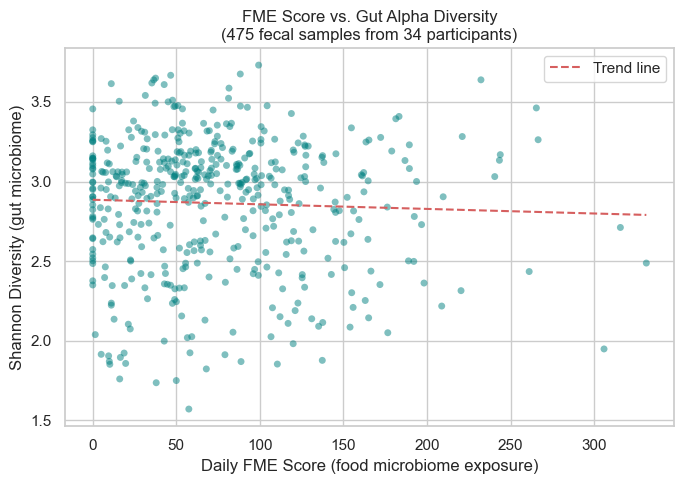

In [21]:
# ── Quick scatter: FME score vs. gut Shannon diversity  ──────
plot_df = statistical_analysis_dataset.dropna(
    subset=["fme_score_daily", "shannon_diversity"]
)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["fme_score_daily"], plot_df["shannon_diversity"],
            alpha=0.5, s=25, c="teal", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_score_daily"], plot_df["shannon_diversity"], 1)
    x_line = np.linspace(plot_df["fme_score_daily"].min(),
                         plot_df["fme_score_daily"].max(), 100)
    plt.plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend line")
plt.xlabel("Daily FME Score (food microbiome exposure)")
plt.ylabel("Shannon Diversity (gut microbiome)")
plt.title("FME Score vs. Gut Alpha Diversity\n(475 fecal samples from 34 participants)")
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 10 – Save Outputs

In [22]:
# ── Save statistical analysis dataset   
statistical_analysis_dataset.to_csv(DATA_DIR / "fme_statistical_dataset_extended.csv")
participant_gut_stability.to_csv(DATA_DIR / "participant_gut_stability.csv", index=False)
fme_with_participant.to_csv(DATA_DIR / "fme_sample_level_scores.csv", index=False)

print("Saved:")
print(f"  fme_statistical_dataset_extended.csv    {statistical_analysis_dataset.shape}  — main analytical table")
print(f"  participant_gut_stability.csv  {participant_gut_stability.shape}  — stability per participant")
print(f"  fme_sample_level_scores.csv    {fme_with_participant.shape}  — FME scores with participant labels")


Saved:
  fme_statistical_dataset_extended.csv    (475, 30)  — main analytical table
  participant_gut_stability.csv  (34, 5)  — stability per participant
  fme_sample_level_scores.csv    (475, 4)  — FME scores with participant labels


---
## Summary

### What was built
The `fme_statistical_dataset.csv` table is the **primary input for all statistical analyses**.

### Structural note (important for modelling)
- **Unit of observation**: fecal sample (475 rows)
- **Grouping variable**: `participant_id` (34 participants) → must be included as a **random effect**
- **Main predictor**: `fme_score_daily`
- **Main outcomes**: `shannon_diversity` (composition), `participant_shannon_cv` (stability)

### Recommended next steps
```
Mixed-effects model (composition):
  shannon_diversity ~ fme_score_daily + Age + BMI + KCAL + (1 | participant_id)

Mixed-effects model (stability — participant level, n=34):
  participant_shannon_cv ~ mean(fme_score_daily) + Age + BMI
```
